          ds     y
0 2009-01-01  4182
1 2009-04-01  5012
2 2009-07-01  4823
3 2009-10-01  4853
4 2010-01-01  5330


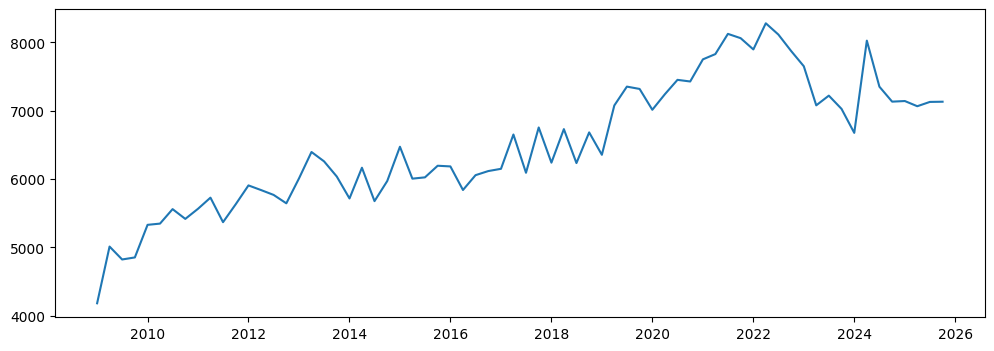

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

path = "/Users/lauriwikberg/Desktop/pr/kruna.csv"

df = pd.read_csv(path, sep=";")

df.columns = ["ds", "y"]

df["ds"] = pd.PeriodIndex(df["ds"], freq = "Q").to_timestamp()

print(df.head())

plt.figure(figsize=(12, 4))
plt.plot(df["ds"], df["y"])

Total observations: 68
Train size: 45 (66.2%)
Test size: 23 (33.8%)

Date ranges:
Train: 2009-01-01 to 2020-01-01
Test : 2020-04-01 to 2025-10-01


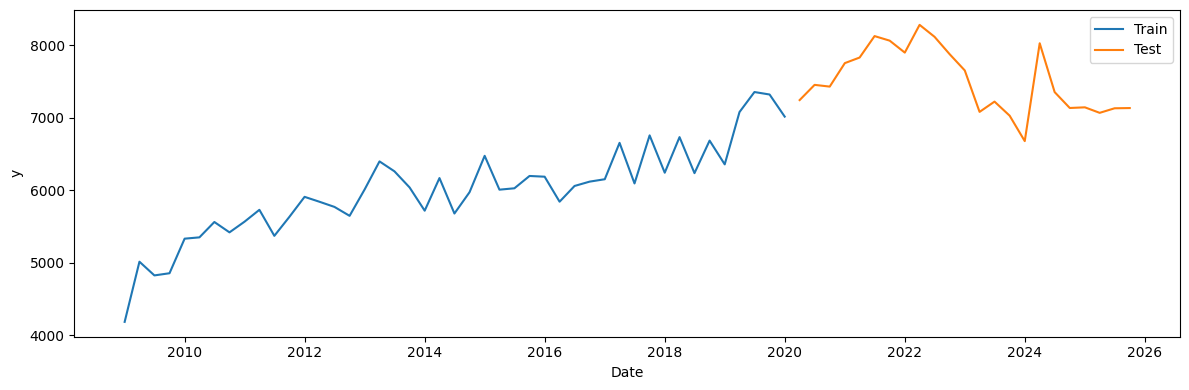

In [2]:
train_fac = 0.675
test_fac = 1-train_fac

n = len(df)

train_end = int(train_fac * n)

train_df = df.iloc[:train_end].copy()
test_df = df.iloc[train_end:].copy()

print("Total observations:", n)
print("Train size:", len(train_df), f"({len(train_df)/n:.1%})")
print("Test size:", len(test_df), f"({len(test_df)/n:.1%})")

print("\nDate ranges:")
print("Train:", train_df["ds"].min().date(), "to", train_df["ds"].max().date())
print("Test :", test_df["ds"].min().date(), "to", test_df["ds"].max().date())

plt.figure(figsize=(12, 4))
plt.plot(train_df["ds"], train_df["y"], label="Train")
plt.plot(test_df["ds"], test_df["y"], label="Test")
plt.xlabel("Date")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

17:37:10 - cmdstanpy - INFO - Chain [1] start processing
17:37:11 - cmdstanpy - INFO - Chain [1] done processing


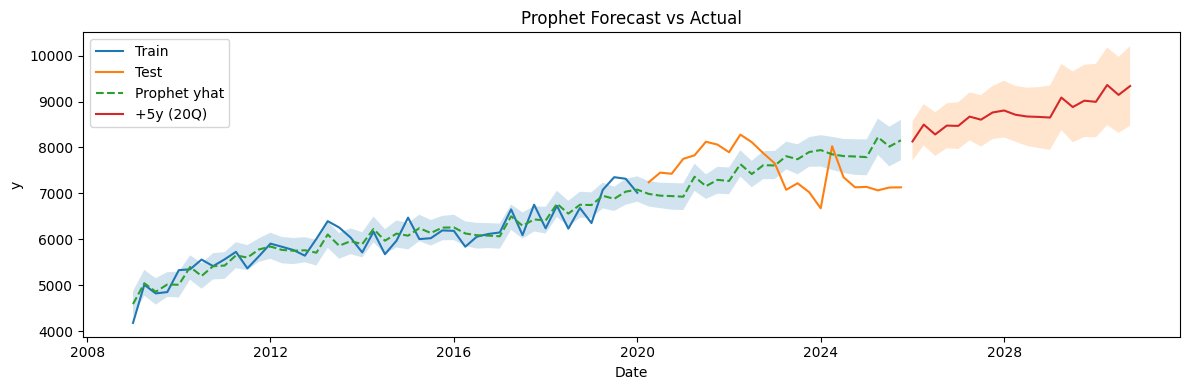

In [3]:
from prophet import Prophet

prophet_train = train_df[["ds", "y"]].copy()

model = Prophet(yearly_seasonality=True, 
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.1)


model.fit(prophet_train)

future_all = pd.DataFrame({"ds": df["ds"]})

forecast_all = model.predict(future_all)[["ds", "yhat", "yhat_lower", "yhat_upper"]]

pred_df = df[["ds", "y"]].merge(forecast_all, on="ds", how="left")

future = model.make_future_dataframe(periods = len(test_df) + 20, freq = "QS")

forecast = model.predict(future)[["ds", "yhat", "yhat_lower", "yhat_upper"]]

future_forecast = forecast[forecast["ds"] > test_df["ds"].max()]

plt.figure(figsize=(12, 4))
plt.plot(train_df["ds"], train_df["y"], label="Train")
plt.plot(test_df["ds"], test_df["y"], label="Test")
plt.plot(pred_df["ds"], pred_df["yhat"], label="Prophet yhat", linestyle="--")
plt.fill_between(
    pred_df["ds"].values,
    pred_df["yhat_lower"].values,
    pred_df["yhat_upper"].values,
    alpha=0.2,
)
plt.plot(future_forecast["ds"], future_forecast["yhat"], label = "+5y (20Q)")
plt.fill_between(
    future_forecast["ds"].values,
    future_forecast["yhat_lower"].values,
    future_forecast["yhat_upper"].values,
    alpha=0.2,
)
plt.title("Prophet Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()
